## Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = 'data'              # folder of raw data
PROCESSED_DIR = 'processed'    # folder of saved cleaned and processed data


## read data 

In [ ]:
ratings = pd.read_csv(os.path.join(DATA_DIR, 'ratings.csv'))
movies  = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
tags    = pd.read_csv(os.path.join(DATA_DIR, 'tags.csv'))
links   = pd.read_csv(os.path.join(DATA_DIR, 'links.csv'))

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
print("tags shape:", tags.shape)
print("links shape:", links.shape)


Ratings shape: (100836, 4)
Movies shape: (9742, 3)
Tags shape: (3683, 4)
Links shape: (9742, 3)


In [6]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [7]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [8]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [9]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## check missing values

In [5]:
print("\nRatings:\n", ratings.isnull().sum())
print("\nMovies:\n", movies.isnull().sum())
print("\nTags:\n", tags.isnull().sum())
print("\nLinks:\n", links.isnull().sum())



Ratings:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Movies:
 movieId    0
title      0
genres     0
dtype: int64

Tags:
 userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Links:
 movieId    0
imdbId     0
tmdbId     8
dtype: int64


## check duplicates

In [10]:
# Check for duplicate rows
print("duplicate ratings:", ratings.duplicated().sum())
print("duplicate movies:", movies.duplicated().sum())
print("duplicate tags:", tags.duplicated().sum())
print("duplicate links:", links.duplicated().sum())


duplicate ratings: 0
duplicate movies: 0
duplicate tags: 0
duplicate links: 0


## Exploratory Data Analysis (EDA)


### rating distribution

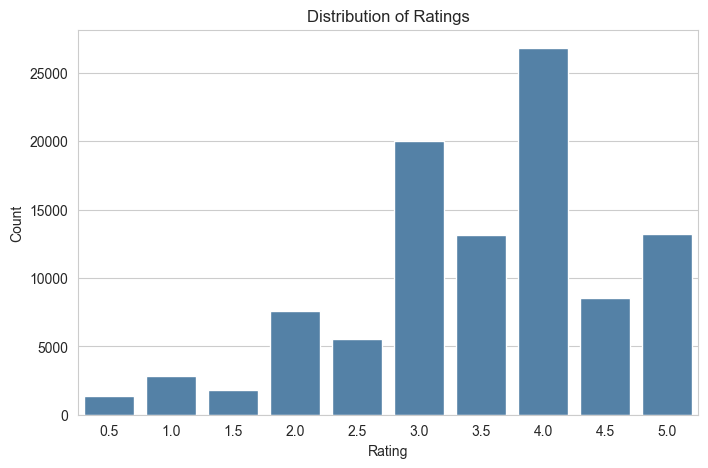

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x='rating', data=ratings, color='steelblue')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

### Number of ratings per user


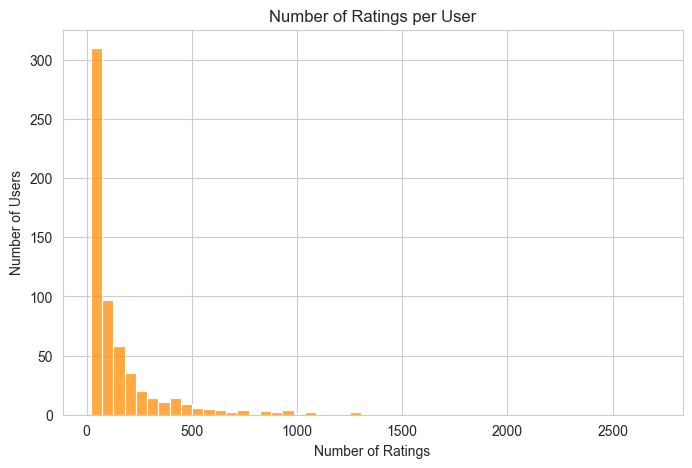

count     610.000000
mean      165.304918
std       269.480584
min        20.000000
25%        35.000000
50%        70.500000
75%       168.000000
max      2698.000000
dtype: float64


In [12]:
ratings_per_user = ratings.groupby('userId').size()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_user, bins=50, color='darkorange')
plt.title('Number of Ratings per User')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Users')
plt.show()

print(ratings_per_user.describe())


### ratings per movie

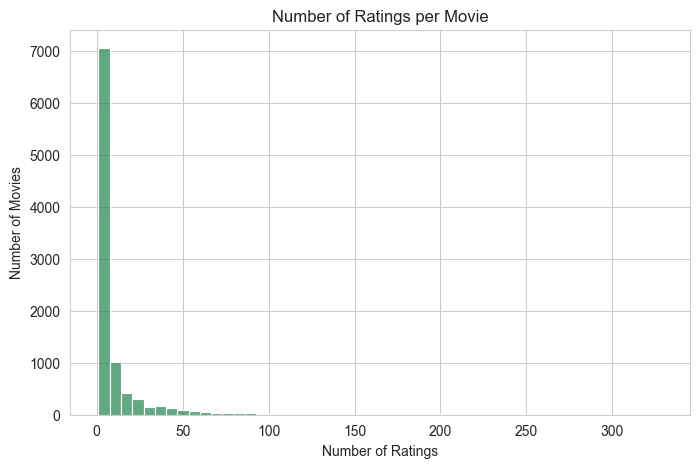

count    9724.000000
mean       10.369807
std        22.401005
min         1.000000
25%         1.000000
50%         3.000000
75%         9.000000
max       329.000000
dtype: float64


In [13]:
ratings_per_movie = ratings.groupby('movieId').size()

plt.figure(figsize=(8,5))
sns.histplot(ratings_per_movie, bins=50, color='seagreen')
plt.title('Number of Ratings per Movie')
plt.xlabel('Number of Ratings')
plt.ylabel('Number of Movies')
plt.show()

print(ratings_per_movie.describe())


### top 10 rated movies


In [14]:
top_movies = ratings.groupby('movieId').size().sort_values(ascending=False).head(10)
top_movies_df = movies.set_index('movieId').loc[top_movies.index]
top_movies_df['num_ratings'] = top_movies.values
top_movies_df[['title', 'num_ratings']]


,title,num_ratings
movieId,,
356,Forrest Gump (1994),329
318,"Shawshank Redemption, The (1994)",317
296,Pulp Fiction (1994),307
593,"Silence of the Lambs, The (1991)",279
2571,"Matrix, The (1999)",278
260,Star Wars: Episode IV - A New Hope (1977),251
480,Jurassic Park (1993),238
110,Braveheart (1995),237
589,Terminator 2: Judgment Day (1991),224


### Explore genres


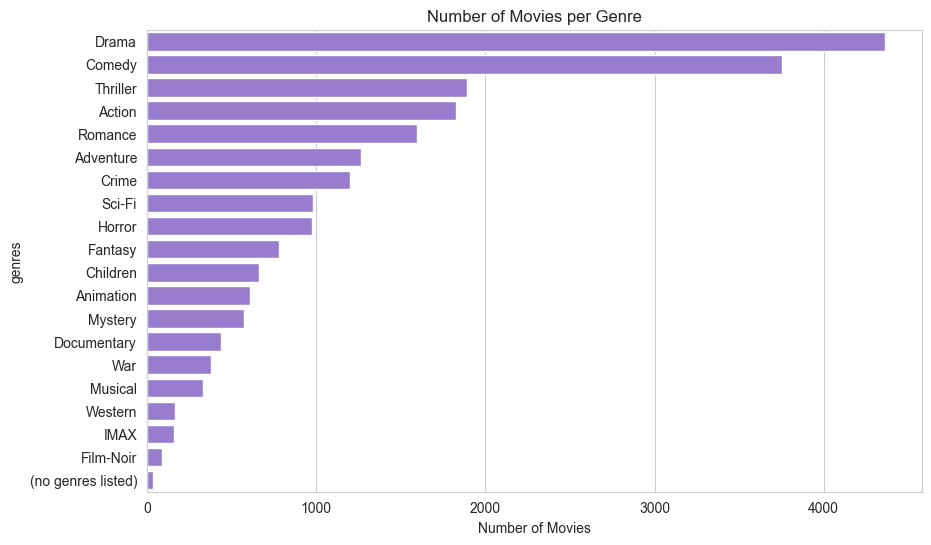

In [15]:
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, color='mediumpurple')
plt.title('Number of Movies per Genre')
plt.xlabel('Number of Movies')
plt.show()


### sparsity of the user-item matrix (important concept from the lecture)


In [16]:
n_users = ratings['userId'].nunique()
n_movies = movies['movieId'].nunique()
n_ratings = len(ratings)

possible_ratings = n_users * n_movies
sparsity = 1 - (n_ratings / possible_ratings)

print(f"Users: {n_users}, Movies: {n_movies}")
print(f"Possible user-item pairs: {possible_ratings:,}")
print(f"Actual ratings: {n_ratings:,}")
print(f"Matrix Sparsity: {sparsity:.4%}")


Users: 610, Movies: 9742
Possible user-item pairs: 5,942,620
Actual ratings: 100,836
Matrix Sparsity: 98.3032%


Steps:
- Extract the **release year** from movie titles
- Clean the title (remove year)
- Split genres into a list
- Handle the no genre case

In [17]:
movies_clean = movies.copy()

movies_clean['year'] = movies_clean['title'].str.extract(r'\((\d{4})\)$')
movies_clean['year'] = pd.to_numeric(movies_clean['year'], errors='coerce')

movies_clean['clean_title'] = movies_clean['title'].str.replace(r'\s*\(\d{4}\)$', '', regex=True)

movies_clean['genres_list'] = movies_clean['genres'].apply(
    lambda x: [] if x == '(no genres listed)' else x.split('|')
)

movies_clean.head()


,movieId,title,genres,year,clean_title,genres_list
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,[Comedy]


### Check how many movies have missing year or no genres


In [18]:
print("movies with missing year:", movies_clean['year'].isnull().sum())
print("movies with no genres listed:", (movies_clean['genres'] == '(no genres listed)').sum())


movies with missing year: 24
movies with no genres listed: 34


### aggregate tags per movie 


In [19]:
movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x.astype(str))).reset_index()
movie_tags.columns = ['movieId', 'all_tags']
movie_tags.head()


,movieId,all_tags
0,1,pixar pixar fun
1,2,fantasy magic board game Robin Williams game
2,3,moldy old
3,5,pregnancy remake
4,7,remake


### merge everything into one dataframe


In [20]:
movies_full = movies_clean.merge(movie_tags, on='movieId', how='left')
movies_full = movies_full.merge(links, on='movieId', how='left')
movies_full['all_tags'] = movies_full['all_tags'].fillna('')

movies_full.head()


,movieId,title,genres,year,clean_title,genres_list,all_tags,imdbId,tmdbId
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",pixar pixar fun,114709,862.0
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0,Jumanji,"[Adventure, Children, Fantasy]",fantasy magic board game Robin Williams game,113497,8844.0
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0,Grumpier Old Men,"[Comedy, Romance]",moldy old,113228,15602.0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995.0,Waiting to Exhale,"[Comedy, Drama, Romance]",,114885,31357.0
4,5,Father of the Bride Part II (1995),Comedy,1995.0,Father of the Bride Part II,[Comedy],pregnancy remake,113041,11862.0


### Create encodings


In [21]:
unique_user_ids = ratings['userId'].unique()
unique_movie_ids = ratings['movieId'].unique()

user_to_idx = {uid: idx for idx, uid in enumerate(unique_user_ids)}
idx_to_user = {idx: uid for uid, idx in user_to_idx.items()}

movie_to_idx = {mid: idx for idx, mid in enumerate(unique_movie_ids)}
idx_to_movie = {idx: mid for mid, idx in movie_to_idx.items()}

print("Number of unique users encoded:", len(user_to_idx))
print("Number of unique movies encoded:", len(movie_to_idx))


Number of unique users encoded: 610
Number of unique movies encoded: 9724


### apply encoding to ratings dataframe


In [22]:
ratings_encoded = ratings.copy()
ratings_encoded['user_idx'] = ratings_encoded['userId'].map(user_to_idx)
ratings_encoded['movie_idx'] = ratings_encoded['movieId'].map(movie_to_idx)

ratings_encoded.head()


,userId,movieId,rating,timestamp,user_idx,movie_idx
0,1,1,4.0,964982703,0,0
1,1,3,4.0,964981247,0,1
2,1,6,4.0,964982224,0,2
3,1,47,5.0,964983815,0,3
4,1,50,5.0,964982931,0,4


## Train / Validation / Test Split
### split ratio: **80% train / 10% validation / 10% test**


In [23]:
from sklearn.model_selection import train_test_split

train_list, val_list, test_list = [], [], []

for uid, group in ratings_encoded.groupby('userId'):
    if len(group) < 5:
        train_list.append(group)
        continue
    train_part, temp_part = train_test_split(group, test_size=0.2, random_state=42)
    val_part, test_part = train_test_split(temp_part, test_size=0.5, random_state=42)
    train_list.append(train_part)
    val_list.append(val_part)
    test_list.append(test_part)

train_df = pd.concat(train_list).reset_index(drop=True)
val_df = pd.concat(val_list).reset_index(drop=True) if val_list else pd.DataFrame(columns=ratings_encoded.columns)
test_df = pd.concat(test_list).reset_index(drop=True) if test_list else pd.DataFrame(columns=ratings_encoded.columns)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df), "== Original:", len(ratings_encoded))


Train size: 80419
Validation size: 10059
Test size: 10358
Total: 100836 == Original: 100836


## Save Processed Data

In [24]:
import pickle

train_df.to_csv(os.path.join(PROCESSED_DIR, 'train.csv'), index=False)
val_df.to_csv(os.path.join(PROCESSED_DIR, 'val.csv'), index=False)
test_df.to_csv(os.path.join(PROCESSED_DIR, 'test.csv'), index=False)

movies_full.to_csv(os.path.join(PROCESSED_DIR, 'movies_full.csv'), index=False)

ratings_encoded.to_csv(os.path.join(PROCESSED_DIR, 'ratings_encoded.csv'), index=False)

mappings = {
    'user_to_idx': user_to_idx,
    'idx_to_user': idx_to_user,
    'movie_to_idx': movie_to_idx,
    'idx_to_movie': idx_to_movie,
    'n_users': len(user_to_idx),
    'n_movies': len(movie_to_idx)
}

with open(os.path.join(PROCESSED_DIR, 'mappings.pkl'), 'wb') as f:
    pickle.dump(mappings, f)

